<a href="https://colab.research.google.com/github/carlos-osorio/monitor-portuario/blob/main/notebooks/03_backtest_export.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import pandas as pd
import numpy as np

# Ajusta el nombre al snapshot más reciente que veas en data/ del repo
URL = ("https://raw.githubusercontent.com/carlos-osorio/monitor-portuario/"
       "main/data/portwatch_2026-07-09.csv")

df = pd.read_csv(URL, parse_dates=["date"])

# Serie semanal de importaciones por puerto (indicador principal)
sem = (df.set_index("date")
         .groupby("portname")["export"]
         .resample("W").sum()
         .unstack(level=0))          # → una columna por puerto

sem = sem.iloc[:-1]                  # excluir la última semana (parcial) — regla del contrato
print(sem.tail(3))

portname    Barranquilla  Buenaventura  Cartagena  Santa Marta
date                                                          
2026-06-14         75074          7571     398507        90482
2026-06-21         36642         32795     453490        56668
2026-06-28         43113         58827     285075        15928


Rango de factores estacionales por puerto:
     Barranquilla  Buenaventura  Cartagena  Santa Marta
min          0.57          0.45       0.71         0.45
max          1.65          2.40       1.52         2.24


<Axes: title={'center': 'Factor estacional por semana del año'}, xlabel='semana'>

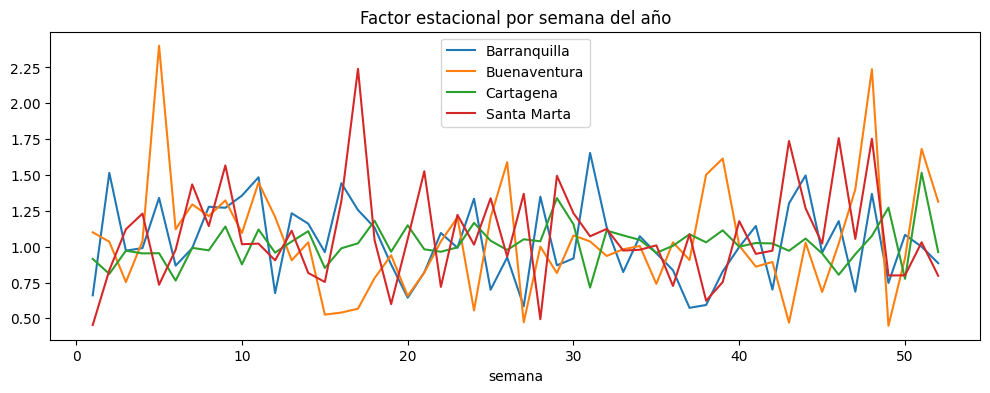

In [2]:
factores = {}

for puerto in sem.columns:
    s = sem[puerto].dropna().to_frame("valor")
    s["anio"] = s.index.year
    s["semana"] = s.index.isocalendar().week.astype(int)
    s = s[s["semana"] <= 52]                      # descarta la semana 53 (pocos años la tienen)

    nivel_anual = s.groupby("anio")["valor"].transform("median")
    s["ratio"] = s["valor"] / nivel_anual         # forma del año, sin tendencia

    factores[puerto] = s.groupby("semana")["ratio"].median()

tabla_factores = pd.DataFrame(factores)

print("Rango de factores estacionales por puerto:")
print(tabla_factores.agg(["min", "max"]).round(2))

tabla_factores.plot(figsize=(12, 4), title="Factor estacional por semana del año")

In [3]:
K = 13          # ventana: un trimestre
UMBRALES = [3.0, 3.5, 4.0]

def z_modificado(serie, k=K):
    """z robusto de cada semana contra la ventana de las k semanas ANTERIORES."""
    mediana_movil = serie.rolling(k).median().shift(1)          # solo pasado
    mad_movil = (serie.rolling(k)
                       .apply(lambda v: np.median(np.abs(v - np.median(v))), raw=True)
                       .shift(1))
    return 0.6745 * (serie - mediana_movil) / mad_movil

zs = sem.apply(z_modificado)

# Conteo de alertas históricas por umbral — solo CAÍDAS (z negativo), como acordamos
print("Alertas por año (total 4 puertos, ~7.5 años de historia):")
for T in UMBRALES:
    alertas = (zs <= -T)
    print(f"  |z| > {T}: {int(alertas.sum().sum())} alertas "
          f"→ {alertas.sum().sum() / 7.5:.1f} por año")

Alertas por año (total 4 puertos, ~7.5 años de historia):
  |z| > 3.0: 14 alertas → 1.9 por año
  |z| > 3.5: 7 alertas → 0.9 por año
  |z| > 4.0: 5 alertas → 0.7 por año


Proporción de semanas fuera de [0.9, 1.1]:
Barranquilla    0.73
Buenaventura    0.63
Cartagena       0.37
Santa Marta     0.65
dtype: float64

Factores en semanas de fiestas:
        Barranquilla  Buenaventura  Cartagena  Santa Marta
semana                                                    
1               0.66          1.10       0.91         0.45
2               1.52          1.03       0.81         0.84
51              1.00          1.68       1.52         1.03
52              0.89          1.31       0.96         0.80


<Axes: title={'center': 'Factores suavizados (mediana móvil de 5 semanas)'}, xlabel='semana'>

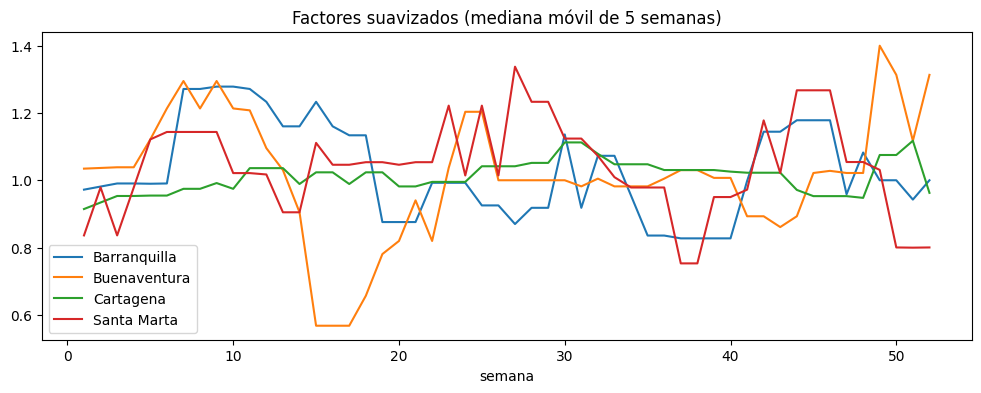

In [4]:
# ¿Qué fracción de semanas sale de la banda ±10%? (mejor resumen que min/max)
fuera = ((tabla_factores < 0.9) | (tabla_factores > 1.1)).mean().round(2)
print("Proporción de semanas fuera de [0.9, 1.1]:")
print(fuera)

# ¿Dónde viven los extremos? Si son las semanas 1-2 y 51-52, es efecto fiestas
print("\nFactores en semanas de fiestas:")
print(tabla_factores.loc[[1, 2, 51, 52]].round(2))

# ¿La curva es suave (estación) o dentada (ruido)? Suavizada para comparar
tabla_factores.rolling(5, center=True, min_periods=1).median().plot(
    figsize=(12, 4), title="Factores suavizados (mediana móvil de 5 semanas)")

In [5]:
# Las fechas: la prueba de sensibilidad y la de especificidad narrativa
T = 3.0
alertas = zs[zs <= -T].stack().sort_index()
for (fecha, puerto), z in alertas.items():
    print(f"{fecha.date()}  {puerto:<14} z = {z:5.1f}")

2019-05-12  Santa Marta    z =  -3.4
2019-06-16  Santa Marta    z =  -3.3
2019-09-15  Cartagena      z =  -4.7
2019-09-22  Cartagena      z =  -3.1
2019-10-06  Cartagena      z =  -3.9
2019-10-20  Buenaventura   z =  -3.3
2019-11-10  Cartagena      z =  -4.0
2019-11-17  Cartagena      z =  -3.4
2020-11-22  Cartagena      z =  -4.2
2021-06-27  Cartagena      z =  -4.0
2021-07-04  Cartagena      z =  -3.4
2022-09-11  Cartagena      z =  -5.8
2022-11-06  Cartagena      z =  -4.3
2024-09-29  Barranquilla   z =  -3.4


In [6]:
# ¿Qué dijo el detector durante el paro? (abril-julio 2021, Buenaventura)
print(zs.loc["2021-04-01":"2021-07-31", "Buenaventura"].round(2))

date
2021-04-04   -0.80
2021-04-11   -0.17
2021-04-18   -1.34
2021-04-25    0.44
2021-05-02   -1.73
2021-05-09    9.85
2021-05-16    2.38
2021-05-23    0.20
2021-05-30   -1.31
2021-06-06   -1.24
2021-06-13   -1.37
2021-06-20   -0.97
2021-06-27   -0.49
2021-07-04   -0.08
2021-07-11    1.16
2021-07-18    1.77
2021-07-25    0.98
Freq: W-SUN, Name: Buenaventura, dtype: float64


In [7]:
# ¿Y durante la pandemia? (marzo-julio 2020, los cuatro puertos)
print(zs.loc["2020-03-01":"2020-07-31"].round(2))

portname    Barranquilla  Buenaventura  Cartagena  Santa Marta
date                                                          
2020-03-01          0.60          0.33       0.70         0.61
2020-03-08         -0.69         -0.12      -0.33        -0.50
2020-03-15          2.81         -1.66       2.02         0.36
2020-03-22         -0.65         -0.22       0.28        -1.88
2020-03-29          1.68         -0.27       2.55        -1.62
2020-04-05          1.11          0.17       0.03         3.64
2020-04-12          0.59         -0.43      -1.86         0.34
2020-04-19          0.41         -1.40       0.33         0.28
2020-04-26         -1.88         -1.38      -1.12        -1.58
2020-05-03          2.32         -0.00      -0.04         0.28
2020-05-10         -1.26          5.25      -0.06        -1.26
2020-05-17         -0.75         -1.21      -0.52        -0.51
2020-05-24         -0.82         -0.04       1.87         4.72
2020-05-31         -0.17          3.14      -0.38      

In [8]:
def cusum_negativo(z, k=0.5):
    """Acumula desviaciones negativas: S_t = min(0, S_{t-1} + z_t + k)."""
    s, out = 0.0, []
    for val in z.fillna(0):
        s = min(0.0, s + val + k)
        out.append(s)
    return pd.Series(out, index=z.index)

cus = zs.apply(cusum_negativo)

# ¿Cuándo habría alertado, con umbral de decisión h?
for h in [4.0, 5.0, 6.0]:
    n = int((cus <= -h).sum().sum())
    print(f"h = {h}: {n} semanas-puerto en alerta → revisa fechas abajo")

h = 5.0
for (fecha, puerto) in cus[cus <= -h].stack().index:
    print(fecha.date(), puerto)

h = 4.0: 50 semanas-puerto en alerta → revisa fechas abajo
h = 5.0: 36 semanas-puerto en alerta → revisa fechas abajo
h = 6.0: 28 semanas-puerto en alerta → revisa fechas abajo
2019-09-22 Cartagena
2019-09-29 Cartagena
2019-10-06 Cartagena
2019-10-13 Cartagena
2019-10-20 Cartagena
2019-10-27 Cartagena
2019-11-03 Cartagena
2019-11-10 Cartagena
2019-11-17 Cartagena
2019-11-24 Cartagena
2019-12-01 Cartagena
2019-12-08 Cartagena
2019-12-15 Cartagena
2019-12-22 Cartagena
2019-12-29 Cartagena
2020-01-05 Cartagena
2020-01-12 Cartagena
2020-01-19 Cartagena
2020-01-26 Cartagena
2020-02-02 Cartagena
2020-02-16 Cartagena
2020-02-23 Cartagena
2020-11-22 Cartagena
2021-07-04 Cartagena
2021-07-11 Cartagena
2022-09-11 Cartagena
2023-05-28 Barranquilla
2023-06-04 Barranquilla
2023-06-11 Barranquilla
2023-06-18 Barranquilla
2023-06-25 Barranquilla
2023-07-02 Barranquilla
2023-07-09 Barranquilla
2023-07-16 Barranquilla
2023-07-23 Barranquilla
2023-07-30 Barranquilla


In [9]:
def cusum_negativo(z, k=0.25):
    """Acumula desviaciones negativas: S_t = min(0, S_{t-1} + z_t + k)."""
    s, out = 0.0, []
    for val in z.fillna(0):
        s = min(0.0, s + val + k)
        out.append(s)
    return pd.Series(out, index=z.index)

cus = zs.apply(cusum_negativo)

# ¿Cuándo habría alertado, con umbral de decisión h?
for h in [4.0, 5.0, 6.0]:
    n = int((cus <= -h).sum().sum())
    print(f"h = {h}: {n} semanas-puerto en alerta → revisa fechas abajo")

h = 5.0
for (fecha, puerto) in cus[cus <= -h].stack().index:
    print(fecha.date(), puerto)

h = 4.0: 116 semanas-puerto en alerta → revisa fechas abajo
h = 5.0: 85 semanas-puerto en alerta → revisa fechas abajo
h = 6.0: 63 semanas-puerto en alerta → revisa fechas abajo
2019-06-16 Santa Marta
2019-06-23 Santa Marta
2019-07-07 Barranquilla
2019-07-14 Barranquilla
2019-07-21 Barranquilla
2019-07-28 Barranquilla
2019-09-22 Cartagena
2019-09-29 Cartagena
2019-10-06 Cartagena
2019-10-13 Cartagena
2019-10-20 Cartagena
2019-10-27 Cartagena
2019-11-03 Cartagena
2019-11-10 Cartagena
2019-11-17 Cartagena
2019-11-24 Cartagena
2019-12-01 Cartagena
2019-12-08 Cartagena
2019-12-15 Cartagena
2019-12-22 Cartagena
2019-12-29 Cartagena
2020-01-05 Cartagena
2020-01-12 Cartagena
2020-01-19 Cartagena
2020-01-26 Cartagena
2020-02-02 Cartagena
2020-02-02 Santa Marta
2020-02-09 Cartagena
2020-02-16 Cartagena
2020-02-23 Cartagena
2020-03-01 Cartagena
2020-03-08 Cartagena
2020-03-15 Cartagena
2020-03-22 Cartagena
2020-03-29 Cartagena
2020-04-12 Cartagena
2020-04-19 Cartagena
2020-04-26 Buenaventura
202